In [99]:
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_energy_data.csv", index_col=0, low_memory=False)

# Convert index to numeric first
df.index = pd.to_numeric(df.index, errors='coerce')

# Now convert UNIX to datetime
df.index = pd.to_datetime(df.index, unit='s')

# Sort index
df = df.sort_index()

print(df.index[:5])

DatetimeIndex(['2016-01-01 05:00:00', '2016-01-01 05:00:01',
               '2016-01-01 05:00:02', '2016-01-01 05:00:03',
               '2016-01-01 05:00:04'],
              dtype='datetime64[s]', name='time', freq=None)


In [100]:
import pandas as pd

df = pd.read_csv("HomeC.csv")

# Convert time to numeric first
df['time'] = pd.to_numeric(df['time'], errors='coerce')

# Now convert Unix → datetime
df['time'] = pd.to_datetime(df['time'], unit='s')

# Set index
df.set_index('time', inplace=True)

# Sort
df.sort_index(inplace=True)

# Fill missing
df.fillna(method='ffill', inplace=True)

# Total power
df['total_power'] = df['House overall [kW]']

print(df.head())
print(df.index)

C:\Users\Admin\AppData\Local\Temp\ipykernel_10016\785478313.py:3: DtypeWarning: Columns (0: time, 1: cloudCover) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("HomeC.csv")


TypeError: NDFrame.fillna() got an unexpected keyword argument 'method'

In [15]:
df_numeric = df.select_dtypes(include=[np.number])

In [16]:
df_hourly = df_numeric.resample('h').mean()
df_daily = df_numeric.resample('d').mean()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10016\3237471161.py:2: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  df_daily = df_numeric.resample('d').mean()


In [17]:
df_hourly['total_power'] = df_hourly['House overall [kW]']
df_daily['total_power'] = df_daily['House overall [kW]']

In [18]:
peak = df_hourly.between_time('18:00', '22:00')['total_power'].mean()
off_peak = df_hourly.between_time('00:00', '06:00')['total_power'].mean()

print("Peak Consumption:", peak)
print("Off-Peak Consumption:", off_peak)

Peak Consumption: 0.865907935031
Off-Peak Consumption: 0.8188852269075164


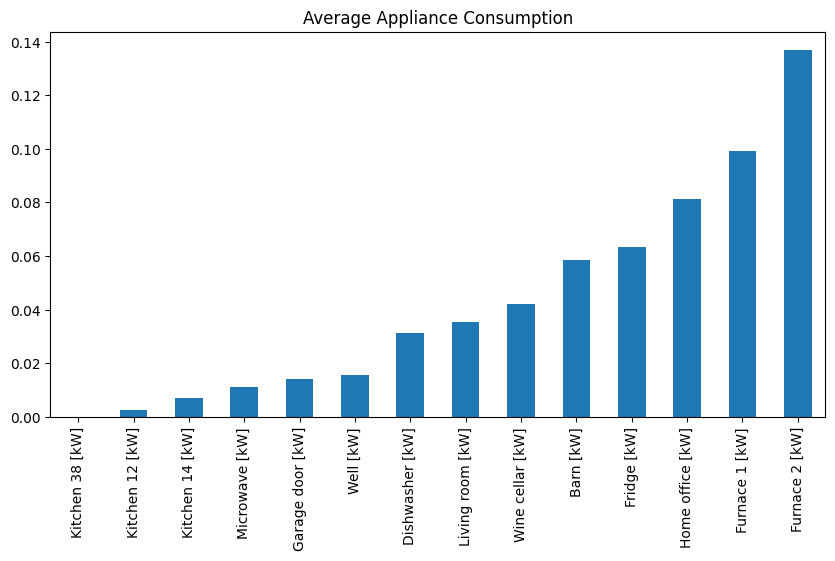

In [20]:
appliances = [
    'Dishwasher [kW]', 'Furnace 1 [kW]', 'Furnace 2 [kW]',
    'Home office [kW]', 'Fridge [kW]', 'Wine cellar [kW]',
    'Garage door [kW]', 'Kitchen 12 [kW]', 'Kitchen 14 [kW]',
    'Kitchen 38 [kW]', 'Barn [kW]', 'Well [kW]',
    'Microwave [kW]', 'Living room [kW]'
]

df_hourly[appliances].mean().sort_values().plot(kind='bar', figsize=(10,5))
plt.title("Average Appliance Consumption")
plt.show()

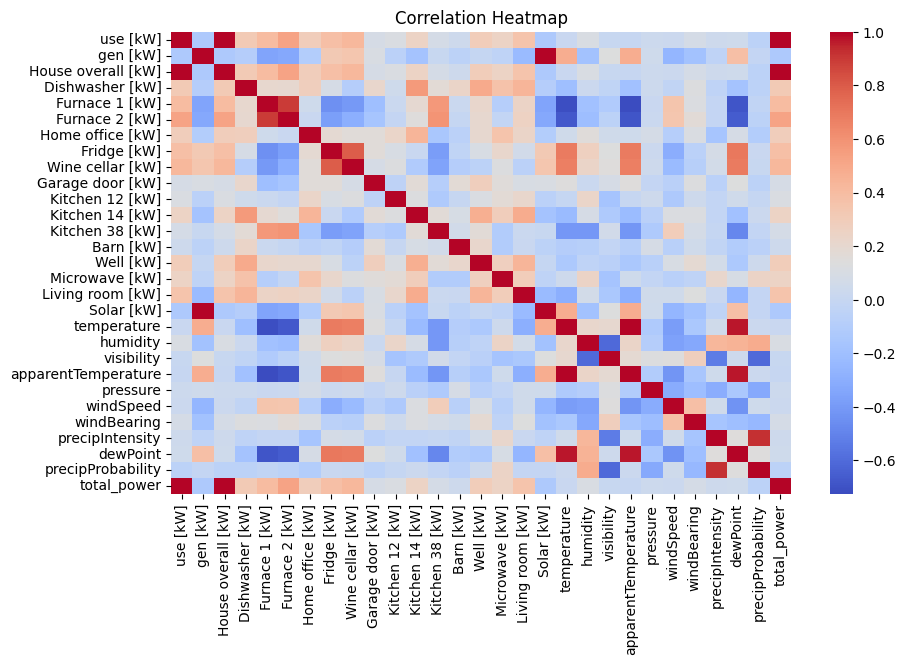

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df_hourly.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

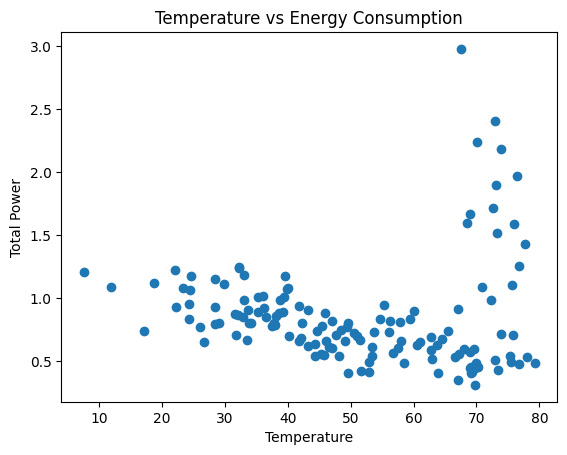

In [22]:
plt.scatter(df_hourly['temperature'], df_hourly['total_power'])
plt.xlabel("Temperature")
plt.ylabel("Total Power")
plt.title("Temperature vs Energy Consumption")
plt.show()

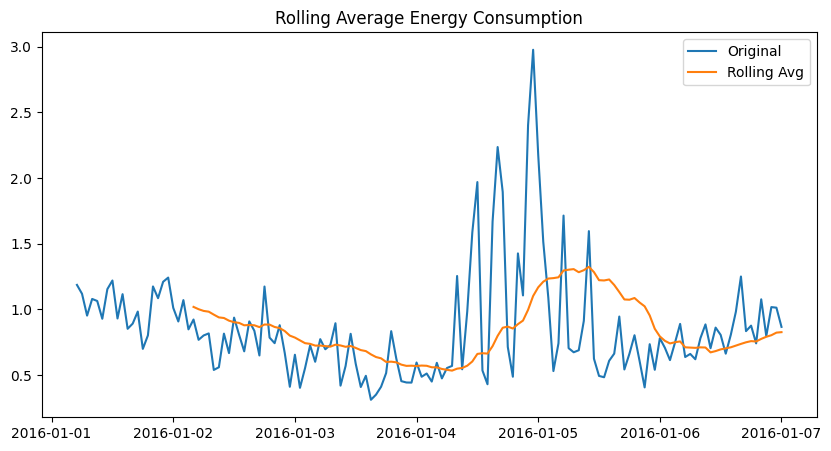

In [23]:
df_hourly['rolling_avg'] = df_hourly['total_power'].rolling(24).mean()

plt.figure(figsize=(10,5))
plt.plot(df_hourly['total_power'], label='Original')
plt.plot(df_hourly['rolling_avg'], label='Rolling Avg')
plt.legend()
plt.title("Rolling Average Energy Consumption")
plt.show()

In [24]:
solar_percent = (df['Solar [kW]'].sum() / df['House overall [kW]'].sum()) * 100
print("Solar Contribution (%):", solar_percent)

Solar Contribution (%): 8.874592890409012


In [36]:
# Combine X and y
data = df[['House overall [kW]', 'temperature', 'humidity', 'windSpeed']].copy()

# Time features
data['hour'] = df.index.hour
data['day'] = df.index.day
data['month'] = df.index.month

# Rename target
data = data.rename(columns={'House overall [kW]': 'total_power'})

# Drop NaN rows
data = data.dropna()

# Split into X and y
X = data[['temperature', 'humidity', 'windSpeed', 'hour', 'day', 'month']]
y = data['total_power']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)

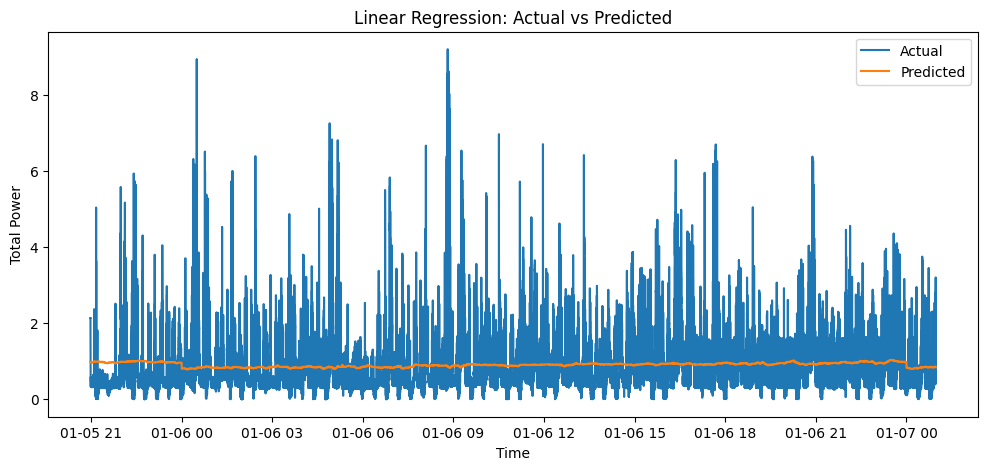

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test.values, label='Actual')
plt.plot(y_test.index, y_pred_lr, label='Predicted')
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Total Power")
plt.legend()
plt.show()

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.4877151143690554
RMSE: 0.6663976618310857


In [42]:
features = ['temperature', 'humidity', 'windSpeed', 'hour', 'day', 'month']

In [45]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [46]:
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

       Feature  Coefficient
1     humidity     0.126653
4          day     0.008062
3         hour     0.007134
2    windSpeed     0.004633
0  temperature     0.000526
5        month     0.000000


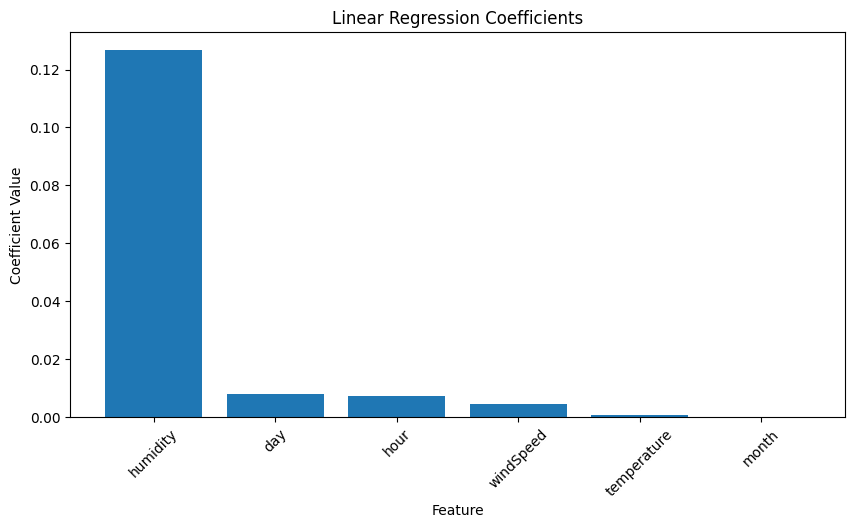

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(coef_df['Feature'], coef_df['Coefficient'])
plt.title("Linear Regression Coefficients")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.show()

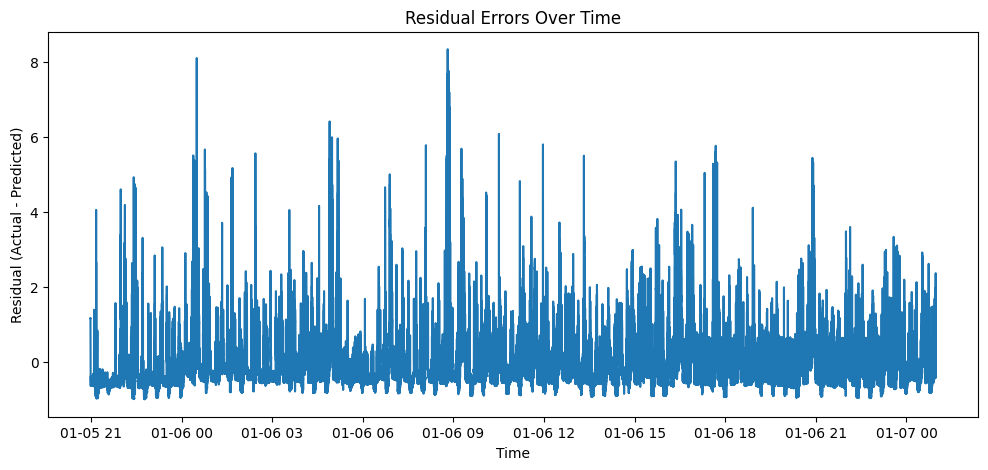

In [49]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(12,5))
plt.plot(y_test.index, residuals)
plt.title("Residual Errors Over Time")
plt.xlabel("Time")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()

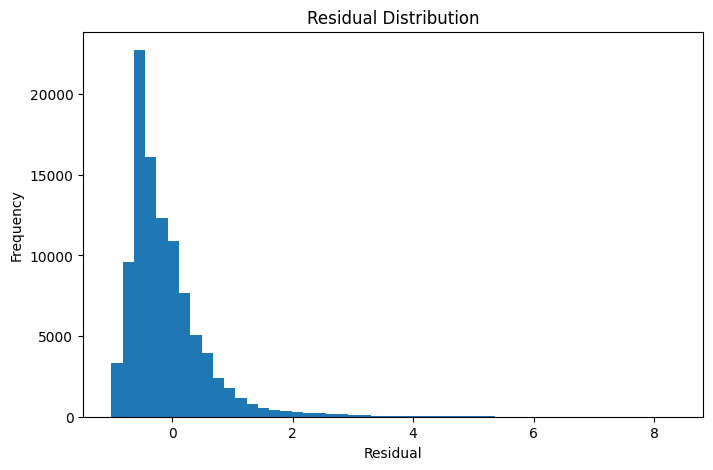

In [50]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [63]:
df_hourly['total_power'] = df_hourly['House overall [kW]']

In [67]:
# Total power
df_hourly['total_power'] = df_hourly['House overall [kW]']

# Lag features
df_hourly['lag_1'] = df_hourly['total_power'].shift(1)
df_hourly['lag_2'] = df_hourly['total_power'].shift(2)
df_hourly['lag_3'] = df_hourly['total_power'].shift(3)
df_hourly['lag_24'] = df_hourly['total_power'].shift(24)

# Drop NaN
df_hourly = df_hourly.dropna()

In [54]:
import numpy as np

X = []
y = []

for i in range(24, len(scaled_data)):
    X.append(scaled_data[i-24:i])  # past 24 hours
    y.append(scaled_data[i])       # next hour

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(116, 24, 1)
(116, 1)


In [68]:
# Total power
df_hourly['total_power'] = df_hourly['House overall [kW]']

# Lag features
df_hourly['lag_1'] = df_hourly['total_power'].shift(1)
df_hourly['lag_2'] = df_hourly['total_power'].shift(2)
df_hourly['lag_3'] = df_hourly['total_power'].shift(3)
df_hourly['lag_24'] = df_hourly['total_power'].shift(24)

# Drop NaN
df_hourly = df_hourly.dropna()

In [69]:
# Features and target
features = ['lag_1', 'lag_2', 'lag_3', 'lag_24']
X = df_hourly[features]
y = df_hourly['total_power']

# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# RMSE
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Forecast RMSE:", rmse)

Forecast RMSE: 0.18081073207560014


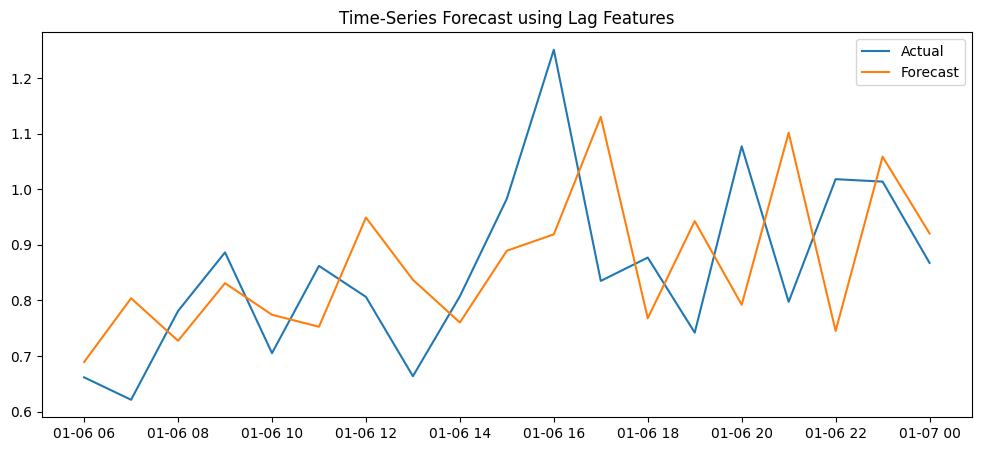

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test.values, label='Actual')
plt.plot(y_test.index, y_pred, label='Forecast')
plt.title("Time-Series Forecast using Lag Features")
plt.legend()
plt.show()

In [72]:
last_values = df_hourly[['lag_1', 'lag_2', 'lag_3', 'lag_24']].iloc[-1]
next_hour = model.predict([last_values])
print("Next Hour Prediction:", next_hour)

Next Hour Prediction: [0.92057027]


C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [73]:
df_hourly['rolling_mean_24'] = df_hourly['total_power'].rolling(24).mean()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10016\3603395918.py:1: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  df_daily = df_hourly.resample('d').mean()


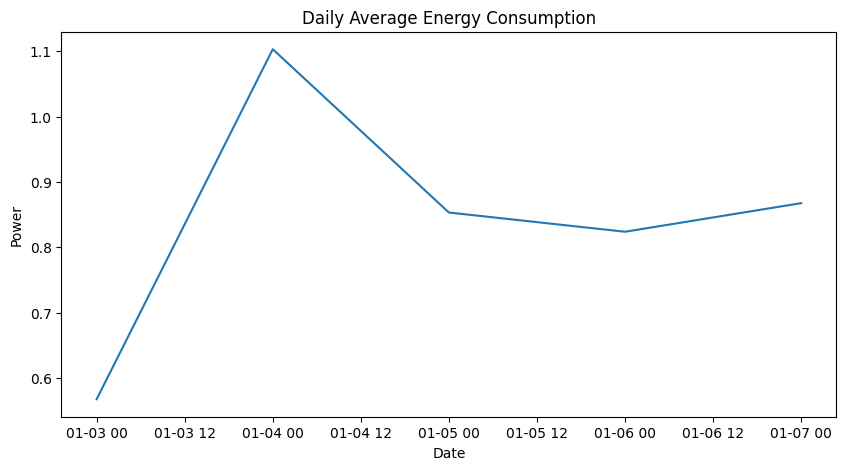

In [75]:
df_daily = df_hourly.resample('d').mean()

plt.figure(figsize=(10,5))
plt.plot(df_daily.index, df_daily['total_power'])
plt.title("Daily Average Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Power")
plt.show()

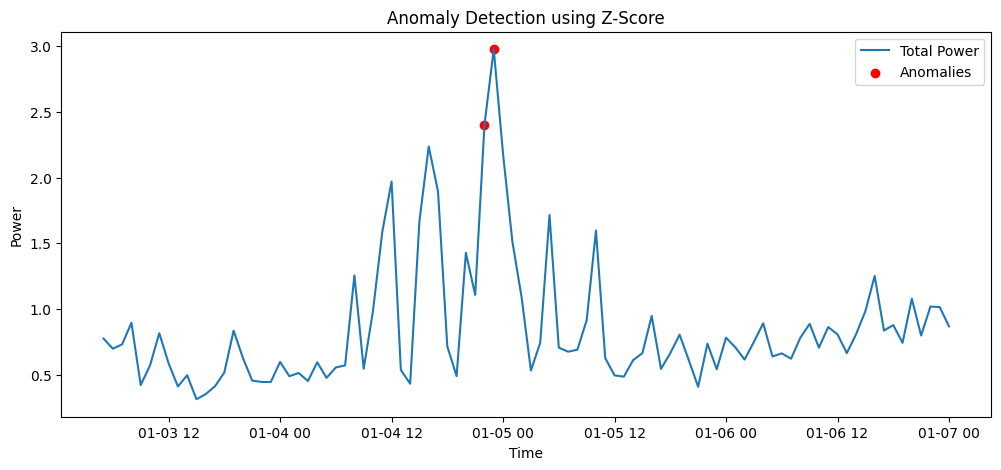

Number of anomalies: 2


In [76]:

z_scores = np.abs((df_hourly['total_power'] - df_hourly['total_power'].mean()) / df_hourly['total_power'].std())
anomalies = df_hourly[z_scores > 3]

plt.figure(figsize=(12,5))
plt.plot(df_hourly.index, df_hourly['total_power'], label='Total Power')
plt.scatter(anomalies.index, anomalies['total_power'], color='red', label='Anomalies')
plt.title("Anomaly Detection using Z-Score")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.show()

print("Number of anomalies:", len(anomalies))

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

device_cols = [
    'Fridge [kW]',
    'Furnace 1 [kW]',
    'Furnace 2 [kW]',
    'Microwave [kW]',
    'Living room [kW]'
]

svm_data = df_hourly[device_cols].dropna().copy()

# Scale data
scaler = StandardScaler()
svm_scaled = scaler.fit_transform(svm_data)

# One-Class SVM
ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)
labels = ocsvm.fit_predict(svm_scaled)

svm_data['anomaly'] = labels
svm_anomalies = svm_data[svm_data['anomaly'] == -1]

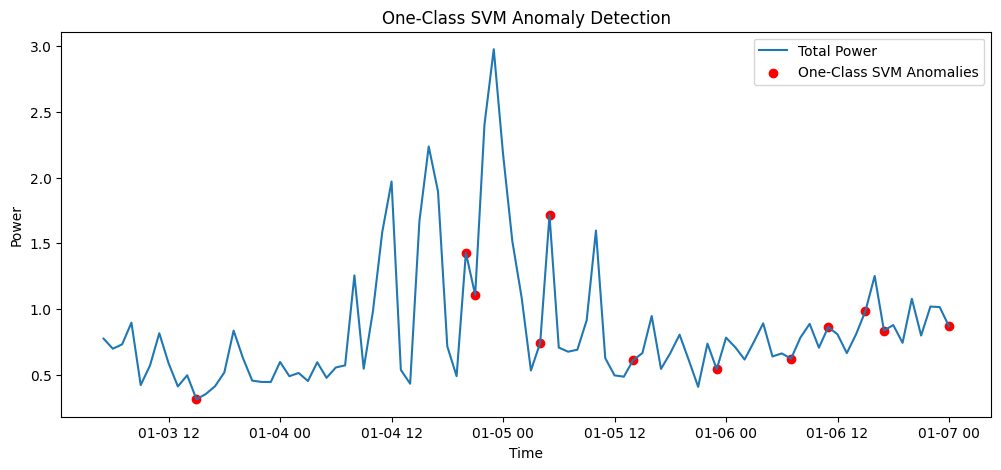

Number of One-Class SVM anomalies: 12


In [78]:
plt.figure(figsize=(12,5))
plt.plot(df_hourly.loc[svm_data.index].index,
         df_hourly.loc[svm_data.index, 'total_power'],
         label='Total Power')

plt.scatter(svm_anomalies.index,
            df_hourly.loc[svm_anomalies.index, 'total_power'],
            color='red', label='One-Class SVM Anomalies')

plt.title("One-Class SVM Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.show()

print("Number of One-Class SVM anomalies:", len(svm_anomalies))

In [80]:
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nDuplicate Timestamps:", df.index.duplicated().sum())
print("\nIndex Type:", df.index.dtype)
print("\nIs Index Sorted:", df.index.is_monotonic_increasing)

Shape: (503911, 35)

Missing Values:
 use [kW]               1
gen [kW]               1
House overall [kW]     1
Dishwasher [kW]        1
Furnace 1 [kW]         1
Furnace 2 [kW]         1
Home office [kW]       1
Fridge [kW]            1
Wine cellar [kW]       1
Garage door [kW]       1
Kitchen 12 [kW]        1
Kitchen 14 [kW]        1
Kitchen 38 [kW]        1
Barn [kW]              1
Well [kW]              1
Microwave [kW]         1
Living room [kW]       1
Solar [kW]             1
temperature            1
icon                   1
humidity               1
visibility             1
summary                1
apparentTemperature    1
pressure               1
windSpeed              1
cloudCover             1
windBearing            1
precipIntensity        1
dewPoint               1
precipProbability      1
total_power            1
hour                   1
day                    1
month                  1
dtype: int64

Duplicate Rows: 171

Duplicate Timestamps: 0

Index Type: datetime64[s]



In [81]:
print("Total anomalies (Z-score):", len(anomalies))
print("Total anomalies (SVM):", len(svm_anomalies))

Total anomalies (Z-score): 2
Total anomalies (SVM): 12


In [88]:
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nDuplicate Timestamps:", df.index.duplicated().sum())
print("\nIndex Type:", df.index.dtype)
print("\nIs Index Sorted:", df.index.is_monotonic_increasing)

Shape: (503911, 32)

Missing Values:
 time                   0
use [kW]               1
gen [kW]               1
House overall [kW]     1
Dishwasher [kW]        1
Furnace 1 [kW]         1
Furnace 2 [kW]         1
Home office [kW]       1
Fridge [kW]            1
Wine cellar [kW]       1
Garage door [kW]       1
Kitchen 12 [kW]        1
Kitchen 14 [kW]        1
Kitchen 38 [kW]        1
Barn [kW]              1
Well [kW]              1
Microwave [kW]         1
Living room [kW]       1
Solar [kW]             1
temperature            1
icon                   1
humidity               1
visibility             1
summary                1
apparentTemperature    1
pressure               1
windSpeed              1
cloudCover             1
windBearing            1
precipIntensity        1
dewPoint               1
precipProbability      1
dtype: int64

Duplicate Rows: 0

Duplicate Timestamps: 0

Index Type: int64

Is Index Sorted: True
